# Interrupted Time Series: FOMC Decisions and Market Volatility

Does a surprise Fed decision move volatility differently than a fully expected one, or does any apparent reaction just reflect a trend that was already underway?

For each event, I fit a linear trend on the 60 trading days beforehand, project it forward as a counterfactual, and compare it to what actually happened afterward.

**Data:** [VIX via FRED](https://fred.stlouisfed.org/series/VIXCLS) · [FOMC dates via the Federal Reserve](https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

PRE_WINDOW = 60
POST_WINDOW = 20

vix = pd.read_csv(
    'https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS&cosd=1990-01-01',
    parse_dates=['observation_date']
)
vix = vix.rename(columns={'observation_date': 'date', 'VIXCLS': 'vix'}).sort_values('date').reset_index(drop=True)
vix['t'] = np.arange(len(vix))
vix.head()

,date,vix,t
0,1990-01-02,17.24,0
1,1990-01-03,18.19,1
2,1990-01-04,19.22,2
3,1990-01-05,20.11,3
4,1990-01-08,20.26,4


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

PRE_WINDOW = 60
POST_WINDOW = 20

vix = pd.read_csv('VIXCLS.csv', parse_dates=['observation_date'])
vix = vix.rename(columns={'observation_date': 'date', 'VIXCLS': 'vix'}).sort_values('date').reset_index(drop=True)
vix['t'] = np.arange(len(vix))
vix.head()

,date,vix,t
0,1990-01-02,17.24,0
1,1990-01-03,18.19,1
2,1990-01-04,19.22,2
3,1990-01-05,20.11,3
4,1990-01-08,20.26,4


In [9]:
def fit_counterfactual(df, event_date):
    idx = df.index[df['date'] >= event_date][0]
    pre = df.iloc[max(0, idx - PRE_WINDOW):idx].dropna(subset=['vix']).copy()
    post = df.iloc[idx:idx + POST_WINDOW].dropna(subset=['vix']).copy()

    x, y = pre['t'].values.astype(float), pre['vix'].values.astype(float)
    n = len(x)
    x_mean, y_mean = x.mean(), y.mean()
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean

    residuals = y - (intercept + slope * x)
    dof = n - 2
    mse = np.sum(residuals ** 2) / dof

    x_post = post['t'].values.astype(float)
    y_hat = intercept + slope * x_post
    se_pred = np.sqrt(mse * (1 + 1/n + (x_post - x_mean)**2 / np.sum((x - x_mean)**2)))
    t_crit = stats.t.ppf(0.975, dof)

    post = post.assign(counterfactual=y_hat, lower=y_hat - t_crit*se_pred, upper=y_hat + t_crit*se_pred)
    post['outside_interval'] = (post['vix'] < post['lower']) | (post['vix'] > post['upper'])

    summary = {
        'slope': slope,
        'pct_days_outside_interval': post['outside_interval'].mean() * 100,
        'avg_gap': (post['vix'] - post['counterfactual']).mean(),
    }
    return pre, post, summary

## Surprise Hold September 17, 2015

In [10]:
pre1, post1, summary1 = fit_counterfactual(vix, pd.Timestamp('2015-09-17'))
summary1

{'slope': np.float64(0.23689808574837426),
 'pct_days_outside_interval': np.float64(15.0),
 'avg_gap': np.float64(-6.7924941525944345)}

## Telegraphed Hike December 13, 2017

In [11]:
pre2, post2, summary2 = fit_counterfactual(vix, pd.Timestamp('2017-12-13'))
summary2

{'slope': np.float64(0.017866544859714735),
 'pct_days_outside_interval': np.float64(22.22222222222222),
 'avg_gap': np.float64(-1.1272306376370689)}

## Visual comparison

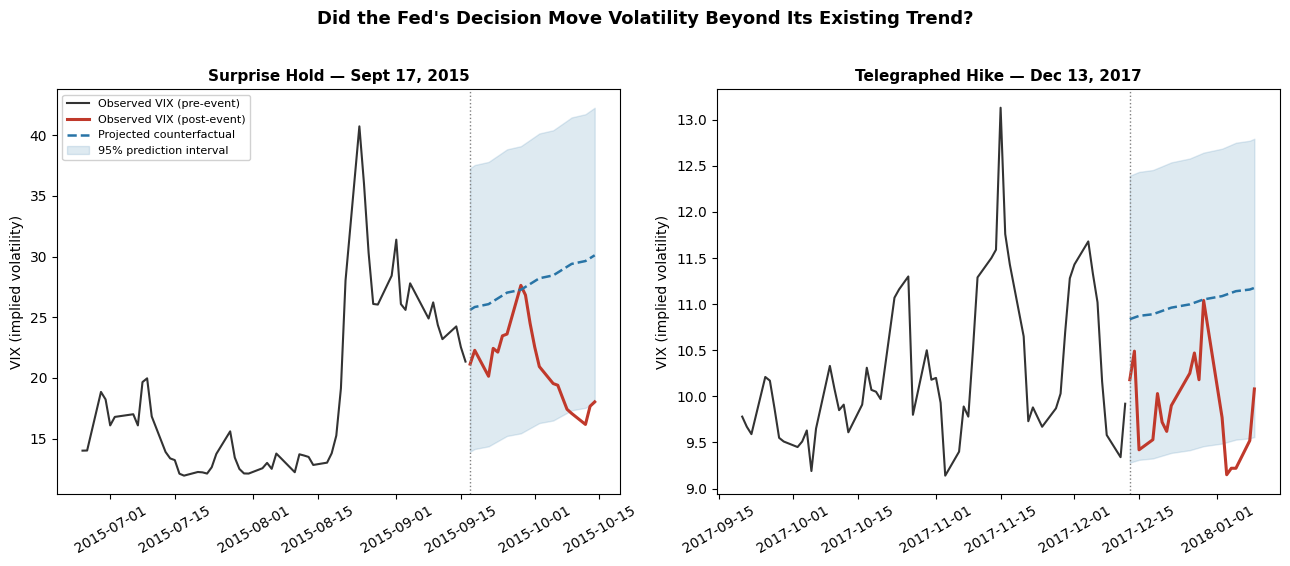

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
events = [(pre1, post1, pd.Timestamp('2015-09-17'), 'Surprise Hold Sept 17, 2015'),
          (pre2, post2, pd.Timestamp('2017-12-13'), 'Telegraphed Hike Dec 13, 2017')]

for (pre, post, event_date, title), ax in zip(events, axes):
    ax.plot(pre['date'], pre['vix'], color='#333333', linewidth=1.5, label='Observed VIX (pre-event)')
    ax.plot(post['date'], post['vix'], color='#c0392b', linewidth=2.2, label='Observed VIX (post-event)')
    ax.plot(post['date'], post['counterfactual'], color='#2874a6', linestyle='--', linewidth=1.8, label='Projected counterfactual')
    ax.fill_between(post['date'], post['lower'], post['upper'], color='#2874a6', alpha=0.15, label='95% prediction interval')
    ax.axvline(event_date, color='gray', linestyle=':', linewidth=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('VIX (implied volatility)')
    ax.tick_params(axis='x', rotation=30)

axes[0].legend(fontsize=8, loc='upper left', framealpha=0.9)
fig.suptitle("Did the Fed's Decision Move Volatility Beyond Its Existing Trend?", fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

---
**Summary:** the surprise decision showed a larger divergence from its pre-event trend than the telegraphed one did. See the full write-up for discussion of what this method can and can't tell you, and its key assumptions.